# Development Benchmark Analysis (Metaheuristics)

**Remark:** this notebook is intended for the **development phase** only, to run controlled experiments and analyze results quickly.

This workflow benchmarks metaheuristic methods one-by-one and in campaign mode without external scripts.

It uses `benchmark.py` with `3_metaheuristics/solver.py`, then extracts key metrics:
- Instances processed
- Average time
- Average bins
- Total elapsed time

In [1]:
from __future__ import annotations

import re
import subprocess
import sys
from pathlib import Path

# Resolve project paths from this notebook location
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
BENCHMARK_FILE = PROJECT_ROOT / "benchmark.py"
SOLVER_REL_PATH = "3_metaheuristics/solver.py"

DATASETS = ["falkenauer-t", "falkenauer-u", "scholl-1", "scholl-2", "scholl-3"]
METHODS = ["sa", "sa reheating", "sa adaptive", "ts", "rts", "lnts", "ts diversified"]

print(f"Project root: {PROJECT_ROOT}")
print(f"Benchmark file exists: {BENCHMARK_FILE.exists()}")

Project root: /home/adem/GitHub/optimization
Benchmark file exists: True


In [6]:
def _strip_ansi(text: str) -> str:
    # Remove terminal color/control sequences from benchmark output.
    return re.sub(r"\x1b\[[0-9;]*[A-Za-z]", "", text)


def _extract(pattern: str, text: str) -> str | None:
    m = re.search(pattern, text, flags=re.MULTILINE)
    return m.group(1).strip() if m else None


def run_single(method: str, dataset: str, max_items: int | None = None, time_limit: float | None = None) -> dict:
    cmd = [
        sys.executable,
        str(BENCHMARK_FILE),
        "--solver",
        SOLVER_REL_PATH,
        "--dataset",
        dataset,
        "--method",
        method,
        "--no-graphs",
    ]
    if max_items is not None:
        cmd += ["--max-items", str(max_items)]
    if time_limit is not None:
        cmd += ["--time-limit", str(time_limit)]

    proc = subprocess.run(
        cmd,
        cwd=PROJECT_ROOT,
        text=True,
        capture_output=True,
        check=False,
    )

    out = _strip_ansi(proc.stdout)
    err = _strip_ansi(proc.stderr)

    result = {
        "dataset": dataset,
        "method": method,
        "exit_code": proc.returncode,
        "instances": _extract(r"Instances processed\s*:\s*(.+)", out),
        "avg_time": _extract(r"Average time \(completed\)\s*:\s*(.+)", out),
        "avg_bins": _extract(r"Average bins \(completed\)\s*:\s*(.+)", out),
        "total_elapsed": _extract(r"Total elapsed time\s*:\s*(.+)", out),
        "stdout": out,
        "stderr": err,
    }
    return result

## 1) Run one test (algorithm + dataset)
Edit `method` and `dataset`, then run the cell.

In [3]:
method = "ts"
dataset = "falkenauer-t"
max_items = 120

single = run_single(method=method, dataset=dataset, max_items=max_items)

print({k: v for k, v in single.items() if k not in {"stdout", "stderr"}})
print()
print("Last output lines:")
print("\n".join(single["stdout"].splitlines()[-20:]))
if single["exit_code"] != 0:
    print("\n[stderr]")
    print(single["stderr"])

{'dataset': 'falkenauer-t', 'method': 'ts', 'exit_code': 0, 'instances': '\x1b 20', 'avg_time': '\x1b 0.2293 s', 'avg_bins': '\x1b 23.20', 'total_elapsed': '\x1b 4.5854 s'}

Last output lines:
Falkenauer_t60_11 │ 60    │ 1000     │ 20 │ 24   │ 4   │ 0.1577     │ ts     │ Done 
Falkenauer_t60_12 │ 60    │ 1000     │ 20 │ 23   │ 3   │ 0.2326     │ ts     │ Done 
Falkenauer_t60_13 │ 60    │ 1000     │ 20 │ 23   │ 3   │ 0.2347     │ ts     │ Done 
Falkenauer_t60_14 │ 60    │ 1000     │ 20 │ 23   │ 3   │ 0.2326     │ ts     │ Done 
Falkenauer_t60_15 │ 60    │ 1000     │ 20 │ 23   │ 3   │ 0.2317     │ ts     │ Done 
Falkenauer_t60_16 │ 60    │ 1000     │ 20 │ 24   │ 4   │ 0.2405     │ ts     │ Done 
Falkenauer_t60_17 │ 60    │ 1000     │ 20 │ 24   │ 4   │ 0.2394     │ ts     │ Done 
Falkenauer_t60_18 │ 60    │ 1000     │ 20 │ 23   │ 3   │ 0.2380     │ ts     │ Done 
Falkenauer_t60_19 │ 60    │ 1000     │ 20 │ 23   │ 3   │ 0.2458     │ ts     │ Done 
──────────────────────────────────────────

## 2) Run campaign mode and present results
Supported modes:
- single: one method + one dataset
- one method over many datasets
- one dataset over many methods
- full matrix: all methods over all datasets

In [17]:
# Choose campaign mode
mode = "dataset_fixed"  # single | dataset_fixed | method_fixed | full_matrix
max_items = 120

if mode == "single":
    fixed_method = "ts"
    fixed_dataset = "falkenauer-t"
    plan = [(fixed_method, fixed_dataset)]
elif mode == "dataset_fixed":
    fixed_dataset = "falkenauer-t"
    plan = [(m, fixed_dataset) for m in METHODS]
elif mode == "method_fixed":
    fixed_method = "ts"
    plan = [(fixed_method, d) for d in DATASETS]
elif mode == "full_matrix":
    plan = [(m, d) for d in DATASETS for m in METHODS]
else:
    raise ValueError(f"Unsupported mode: {mode}")

results = []
for method, dataset in plan:
    print(f"Running method={method} dataset={dataset} ...")
    res = run_single(method=method, dataset=dataset, max_items=max_items)
    results.append({k: v for k, v in res.items() if k not in {"stdout", "stderr"}})

results

Running method=sa dataset=falkenauer-t ...
Running method=sa reheating dataset=falkenauer-t ...
Running method=sa adaptive dataset=falkenauer-t ...
Running method=ts dataset=falkenauer-t ...
Running method=rts dataset=falkenauer-t ...
Running method=lnts dataset=falkenauer-t ...
Running method=ts diversified dataset=falkenauer-t ...


[{'dataset': 'falkenauer-t',
  'method': 'sa',
  'exit_code': 0,
  'instances': '20',
  'avg_time': '0.3876 s',
  'avg_bins': '23.20',
  'total_elapsed': '7.7521 s'},
 {'dataset': 'falkenauer-t',
  'method': 'sa reheating',
  'exit_code': 0,
  'instances': '20',
  'avg_time': '0.3794 s',
  'avg_bins': '23.20',
  'total_elapsed': '7.5878 s'},
 {'dataset': 'falkenauer-t',
  'method': 'sa adaptive',
  'exit_code': 0,
  'instances': '20',
  'avg_time': '0.3932 s',
  'avg_bins': '23.20',
  'total_elapsed': '7.8631 s'},
 {'dataset': 'falkenauer-t',
  'method': 'ts',
  'exit_code': 0,
  'instances': '20',
  'avg_time': '0.2515 s',
  'avg_bins': '23.20',
  'total_elapsed': '5.0290 s'},
 {'dataset': 'falkenauer-t',
  'method': 'rts',
  'exit_code': 0,
  'instances': '20',
  'avg_time': '0.3856 s',
  'avg_bins': '23.20',
  'total_elapsed': '7.7121 s'},
 {'dataset': 'falkenauer-t',
  'method': 'lnts',
  'exit_code': 0,
  'instances': '20',
  'avg_time': '0.8571 s',
  'avg_bins': '23.20',
  'total

,dataset,method,exit_code,instances,avg_time,avg_bins,total_elapsed
0,falkenauer-t,sa,0,20,0.3876 s,23.20,7.7521 s
1,falkenauer-t,sa reheating,0,20,0.3794 s,23.20,7.5878 s
2,falkenauer-t,sa adaptive,0,20,0.3932 s,23.20,7.8631 s
3,falkenauer-t,ts,0,20,0.2515 s,23.20,5.0290 s
4,falkenauer-t,rts,0,20,0.3856 s,23.20,7.7121 s
5,falkenauer-t,lnts,0,20,0.8571 s,23.20,17.1411 s
6,falkenauer-t,ts diversified,0,20,0.9073 s,23.20,18.1451 s


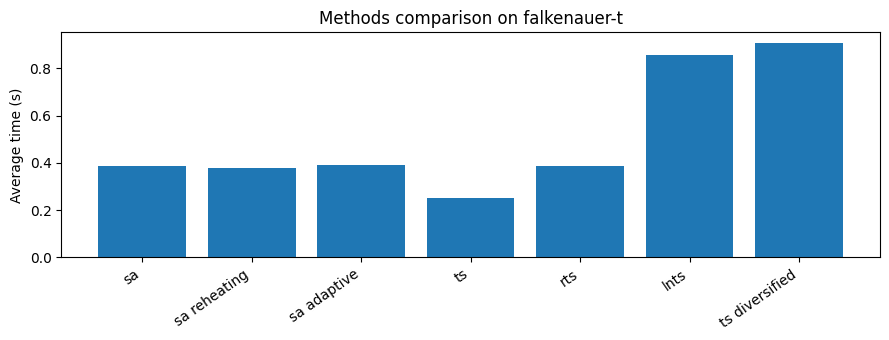

In [18]:
# Present results as a concise table
try:
    import pandas as pd
    from IPython.display import display

    df = pd.DataFrame(results)
    display(df)

    # Optional quick comparison plot when dataset is fixed
    if len(df) > 1 and df["dataset"].nunique() == 1:
        import matplotlib.pyplot as plt

        times = df["avg_time"].str.replace(" s", "", regex=False).astype(float)
        plt.figure(figsize=(9, 3.5))
        plt.bar(df["method"], times)
        plt.ylabel("Average time (s)")
        plt.title(f"Methods comparison on {df['dataset'].iloc[0]}")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.show()
except ImportError:
    # Fallback if pandas is unavailable
    for row in results:
        print(row)

In [19]:
# Optional: export campaign results and full console outputs to results/runlogs
from datetime import datetime
import json

export_dir = PROJECT_ROOT / "results" / "runlogs"
export_dir.mkdir(parents=True, exist_ok=True)

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
summary_path = export_dir / f"notebook_summary_{mode}_{stamp}.tsv"

headers = ["dataset", "method", "exit_code", "instances", "avg_time", "avg_bins", "total_elapsed"]
with summary_path.open("w", encoding="utf-8") as f:
    f.write("\t".join(headers) + "\n")
    for row in results:
        f.write("\t".join(str(row.get(h, "")) for h in headers) + "\n")

for method, dataset in plan:
    out = run_single(method=method, dataset=dataset, max_items=max_items)
    log_name = f"{dataset}__{method.replace(' ', '-')}_notebook_{stamp}.log"
    log_path = export_dir / log_name
    payload = {
        "dataset": out["dataset"],
        "method": out["method"],
        "exit_code": out["exit_code"],
        "instances": out["instances"],
        "avg_time": out["avg_time"],
        "avg_bins": out["avg_bins"],
        "total_elapsed": out["total_elapsed"],
        "stderr": out["stderr"],
        "stdout": out["stdout"],
    }
    log_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")

print(f"Saved summary: {summary_path}")
print(f"Saved logs directory: {export_dir}")

Saved summary: /home/adem/GitHub/optimization/results/runlogs/notebook_summary_dataset_fixed_20260418_161406.tsv
Saved logs directory: /home/adem/GitHub/optimization/results/runlogs
